# 05 - Microglial / astrocytic state marker scores

Score every nucleus for three AD-associated glial states described by Green et al. (2024),
using `sc.tl.score_genes` (mean expression of the state's genes minus a matched random
background).

**Caveat, stated up front:** these are short hand-curated marker sets, and three of the ten
genes (CPM, TREM2, MT1X) are absent from the GSE138852 matrix. A 2-4 gene score is a weak proxy for a
transcriptional state - it is used here as a descriptive axis, not as a cell-type call. The
reference-based labels in notebook 07 are the trustworthy annotation.

Outputs: `results/tables/05_marker_coverage.tsv`, `results/figures/05_marker_scores_umap.png`
(per-nucleus scores are carried into `07_cell_metadata.tsv`).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
from adpipe import *

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

sc.settings.verbosity = 1
adata = sc.read_h5ad(INTERIM / "adata_clustered.h5ad")
print(adata.n_obs, "nuclei x", adata.n_vars, "genes")

13214 nuclei x 10850 genes


In [2]:
MARKER_SETS = {
    "Mic12": ["APOE", "GPNMB", "CPM"],
    "Mic13": ["APOE", "GPNMB", "SPP1", "TREM2", "TPRG1"],
    "Ast10": ["SLC38A2", "MT1E", "MT2A", "MT1X"],
}

coverage = []
for state, genes in MARKER_SETS.items():
    present = [g for g in genes if g in adata.var_names]
    missing = [g for g in genes if g not in adata.var_names]
    coverage.append({"state": state, "n_requested": len(genes), "n_present": len(present),
                     "present": ", ".join(present), "missing": ", ".join(missing) or "-"})

coverage = pd.DataFrame(coverage)
save_table(coverage, "05_marker_coverage", index=False)
coverage

  table -> results/tables/05_marker_coverage.tsv  (3 rows x 5 cols, 0 KB)


,state,n_requested,n_present,present,missing
0,Mic12,3,2,"APOE, GPNMB",CPM
1,Mic13,5,4,"APOE, GPNMB, SPP1, TPRG1",TREM2
2,Ast10,4,3,"SLC38A2, MT1E, MT2A",MT1X


In [3]:
score_cols = []
for state, genes in MARKER_SETS.items():
    present = [g for g in genes if g in adata.var_names]
    col = f"{state}_score"
    sc.tl.score_genes(adata, present, score_name=col, random_state=0)
    score_cols.append(col)

adata.obs[score_cols].describe().round(4)

,Mic12_score,Mic13_score,Ast10_score
count,13214.0000,13214.0000,13214.0000
mean,-0.0046,0.2449,0.0219
std,0.7632,0.4986,0.6605
min,-1.0331,-0.6407,-1.0350
25%,-0.5700,-0.2663,-0.5300
50%,-0.4156,0.2850,-0.2119
75%,0.6545,0.5410,0.4534
max,3.1887,3.6877,3.2002


  figure -> results/figures/05_marker_scores_umap.png  (701 KB)


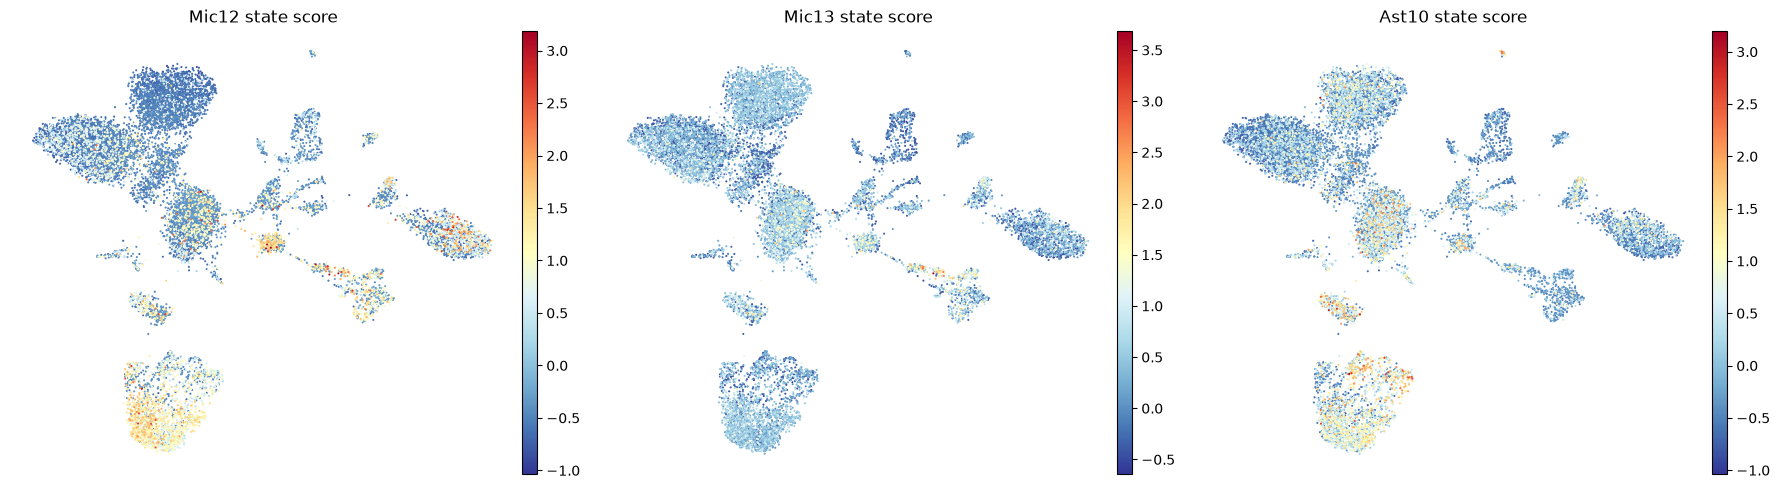

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, score_cols):
    sc.pl.umap(adata, color=col, ax=ax, show=False, frameon=False,
               title=col.replace("_score", " state score"), cmap="RdYlBu_r")
plt.tight_layout()
save_fig(fig, "05_marker_scores_umap")
plt.show()

In [5]:
by_type = adata.obs.groupby("oupSample.cellType", observed=True)[score_cols].mean()
print("mean state score by author cell type:")
display(by_type.round(4))

# Per-nucleus scores go to interim/; notebook 07 folds them into results/tables/07_cell_metadata.tsv
scores = adata.obs[score_cols].copy()
scores.to_csv(INTERIM / "marker_scores.tsv", sep="\t")
print("interim -> interim/marker_scores.tsv")

mean state score by author cell type:


,Mic12_score,Mic13_score,Ast10_score
oupSample.cellType,,,
OPC,0.2078,0.1032,-0.2008
astro,0.7175,0.2713,0.5221
doublet,0.1586,0.3483,0.0878
endo,-0.0645,-0.0033,0.3638
mg,0.5456,0.6628,-0.2195
neuron,-0.1782,-0.0478,-0.3325
oligo,-0.3007,0.2404,-0.0729
unID,0.2232,0.3700,0.1729


interim -> interim/marker_scores.tsv
